## Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Ingestion and Problems

In [10]:
df = pd.read_excel('../Data/option_data_bb_SFRZ5.xlsx', sheet_name='2025-10-10')
spot = pd.read_excel('../Data/option_data_bb_SFRZ5.xlsx', sheet_name='spot')
spot.index = spot['Unnamed: 0']
spot.drop(columns=['Unnamed: 0'], inplace=True)
spot = spot.to_dict()['SFRZ5 Comdty']
spot

{'name': '3 MONTH SOFR FUT  Dec25',
 'last update date': datetime.datetime(2025, 7, 29, 0, 0),
 'last update time': '10:03:48',
 'price': 96.085,
 'hist vol 30d': 0.006850954890251159,
 'hist vol 60d': 0.00759479284286499,
 'volume': 150071}

In [11]:
call = df[df['option type'] == 'C']
call.head(7)

,ticker,last update date,last update time,days to expiration,option type,exercise style,option contract size,strike price,price,finance rate,...,delta,gamma,vega,theta,bid,ask,bid size,ask size,open int,volume
0,SFRV5C 95.75 Comdty,2025-07-28,2025-07-28 00:00:00,73,C,AMER,2500,95.7500,0.3300,0.04396,...,0.899011,0.028984,0.002962,-0.000265,0.335,0.350,51,51,10703,NaN
1,SFRV5C 95.8125 Comdty,2025-07-28,2025-07-28 00:00:00,73,C,AMER,2500,95.8125,0.2775,0.04396,...,0.847946,0.037543,0.003990,-0.000369,0.285,0.295,120,333,0,NaN
2,SFRV5C 95.875 Comdty,2025-07-28,2025-07-28 00:00:00,73,C,AMER,2500,95.8750,0.2325,0.04396,...,0.768768,0.045176,0.005212,-0.000524,0.235,0.245,14976,119,20020,NaN
3,SFRV5C 95.9375 Comdty,2025-07-28,2025-07-28 00:00:00,73,C,AMER,2500,95.9375,0.1950,0.04396,...,0.679044,0.049114,0.006161,-0.000676,0.195,0.205,15838,248,7013,NaN
4,SFRV5C 96 Comdty,2025-07-28,2025-07-28 00:00:00,73,C,AMER,2500,96.0000,0.1600,0.04396,...,0.589523,0.049138,0.006712,-0.000805,0.160,0.175,7500,19302,15635,NaN
5,SFRV5C 96.0625 Comdty,2025-07-28,2025-07-28 00:00:00,73,C,AMER,2500,96.0625,0.1300,0.04396,...,0.506743,0.047811,0.006902,-0.000892,0.135,0.145,100,36274,31106,3882.0
6,SFRV5C 96.125 Comdty,2025-07-28,2025-07-28 00:00:00,73,C,AMER,2500,96.1250,0.1050,0.04396,...,0.430860,0.046676,0.006811,-0.000887,0.105,0.115,37066,8327,43461,2500.0


### 1.1

Use Black’s Formula to price the call option

- at the nearest expiration

- using the ATM strike (strike nearest the spot)

- using the implied vol provided in the data

- using the finance rate as the discount rate

How close is your estimate to the market quote?



In [12]:
closest_call = call.iloc[5,:]
closest_call

ticker                  SFRV5C   96.0625 Comdty
last update date            2025-07-28 00:00:00
last update time            2025-07-28 00:00:00
days to expiration                           73
option type                                   C
exercise style                             AMER
option contract size                       2500
strike price                            96.0625
price                                      0.13
finance rate                            0.04396
time value                               0.1075
implied vol                            0.185438
delta                                  0.506743
gamma                                  0.047811
vega                                   0.006902
theta                                 -0.000892
bid                                       0.135
ask                                       0.145
bid size                                    100
ask size                                  36274
open int                                

In [36]:
from scipy import stats
norm = stats.norm

def duration_closed_formula(tau, ytm, cpnrate=None, freq=2):

    if cpnrate is None:
        cpnrate = ytm
        
    y = ytm/freq
    c = cpnrate/freq
    T = tau * freq
        
    if cpnrate==ytm:
        duration = (1+y)/y  * (1 - 1/(1+y)**T)
        
    else:
        duration = (1+y)/y - (1+y+T*(c-y)) / (c*((1+y)**T-1)+y)

    duration /= freq
    
    return duration


tau = closest_call['days to expiration'] / 365
r = closest_call['finance rate']
rate_vol = closest_call['implied vol']
K = closest_call['strike price']
duration = duration_closed_formula(tau, r)
sigma = rate_vol * r * 1

Z = np.exp(-r * tau)
F = spot['price']

d1 = (np.log(F / K) + (sigma**2 / 2) * tau) / (sigma * np.sqrt(tau))
d2 = d1 - sigma * np.sqrt(tau)

call_price = Z * (F * norm.cdf(d1) - K * norm.cdf(d2))
print(f"Call price: {call_price:.4f}")
print("Tau: " + str(tau))
print("r: " + str(r))
print("duration" + str(duration))
print("sigma: " + str(sigma))
print("K: " + str(K))
print("F: " + str(F))


Call price: 0.1499
Tau: 0.2
r: 0.04396000003814697
duration0.20130544840473277
sigma: 0.00815184525547389
K: 96.0625
F: 96.085


- Using Black's Formula, the call option is priced at $0.1499

### 1.2
Value the entire strike chain for the nearest expiration
- Use the provided implied vol for each strike
Plot the Black Values against the market values

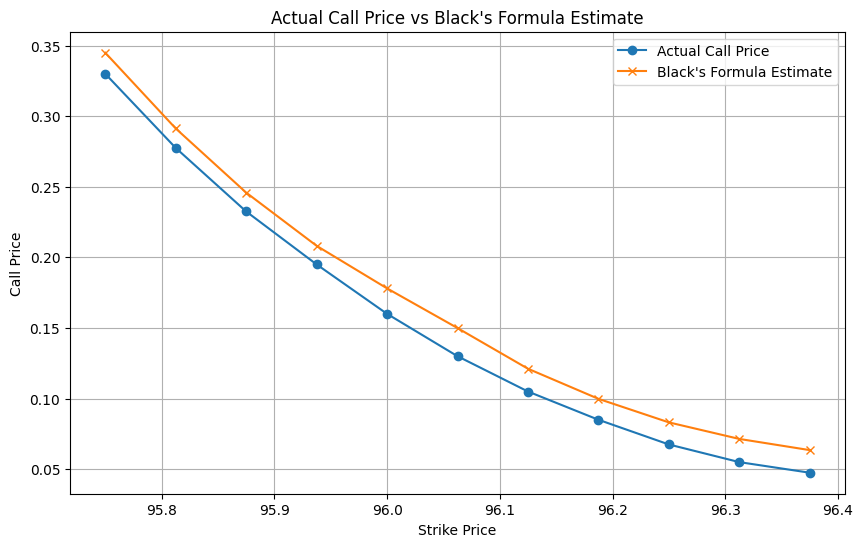

In [41]:
black_estimate = {}
for index, item in call.iterrows():
    tau = item['days to expiration'] / 365
    r = item['finance rate']
    rate_vol = item['implied vol']
    K = item['strike price']
    duration = duration_closed_formula(tau, r)
    sigma = rate_vol * r * 1

    Z = np.exp(-r * tau)
    F = spot['price']

    d1 = (np.log(F / K) + (sigma**2 / 2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)

    call_price = Z * (F * norm.cdf(d1) - K * norm.cdf(d2))
    black_estimate[index] = call_price

plt.figure(figsize=(10,6))
plt.plot(call['strike price'], call['price'], label='Actual Call Price', marker='o')
plt.plot(call['strike price'], list(black_estimate.values()), label='Black\'s Formula Estimate', marker='x')
plt.xlabel('Strike Price')
plt.ylabel('Call Price')
plt.title('Actual Call Price vs Black\'s Formula Estimate')
plt.legend()
plt.grid()
plt.show()

### 1.3 

- Since black's model assumes constant interest rates, this is not realistic for SOFR futures
- The model also does not assume the ability to early exercise, which is not true for American options
- The model also assumes log normal prices, which is not true when prices go negative.


### 1.4
- Implied vol is being quoted as an alternative to price